# Selection function speedup: SGPR vs original

**2026-05-31**

Compare the original (exact-GP, `george`) Quaia G20.5 selection function against the new sparse GP (GPyTorch SGPR) map:

- **orig**: `selection_function_NSIDE64_G20.5.fits` (published, exact george GP)
- **SGPR** (no extra tag): `selection_function_NSIDE64_G20.5_sgpr.fits`

We plot each map, the residual from the original, and summary statistics.

In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
import pandas as pd

import matplotlib
from matplotlib import pyplot as plt

import sys
sys.path.insert(0, '../code')
import utils

%load_ext autoreload
%autoreload 2

cmap_map = 'plasma'
cmap_resid = 'RdBu_r'

In [2]:
G_hi = '20.5'
dir_maps = '../data/maps'

fns = {
    'orig (george)':  f'{dir_maps}/selection_function_NSIDE64_G{G_hi}.fits',
    'SGPR':           f'{dir_maps}/selection_function_NSIDE64_G{G_hi}_sgpr.fits',
}

maps_sf = {name: hp.read_map(fn) for name, fn in fns.items()}
NSIDE = hp.npix2nside(len(maps_sf['orig (george)']))
print('NSIDE:', NSIDE)

# pixels that are populated in the original map (the rest are masked / zero everywhere)
orig = maps_sf['orig (george)']
i_valid = (orig > 0) & np.isfinite(orig)
print('valid (orig>0) pixels:', int(i_valid.sum()), 'of', len(orig))

for name, m in maps_sf.items():
    print(f'{name:18s}  min={np.min(m):.4f}  '
          f'min>0={np.min(m[m>0]):.4f}  max={np.max(m):.4f}  '
          f'n_zero={int(np.sum(m <= 0))}')

NSIDE: 64
valid (orig>0) pixels: 42853 of 49152
orig (george)       min=0.0000  min>0=0.0171  max=0.9614  n_zero=6299
SGPR n_ind=1024     min=0.0000  min>0=0.0173  max=0.9582  n_zero=6299
SGPR n_ind=512      min=0.0000  min>0=0.0169  max=0.9542  n_zero=6299


## Selection function maps

Mollweide projection in Galactic coordinates (input maps are in Celestial / equatorial), completeness scaled 0–1.

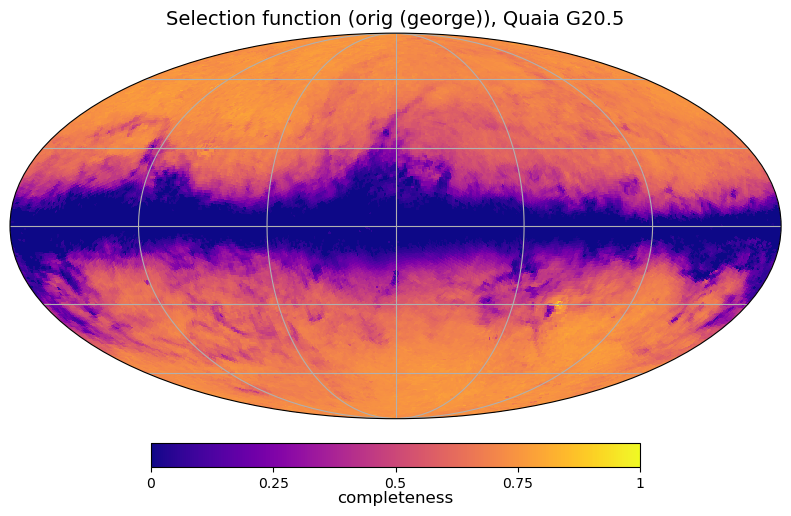

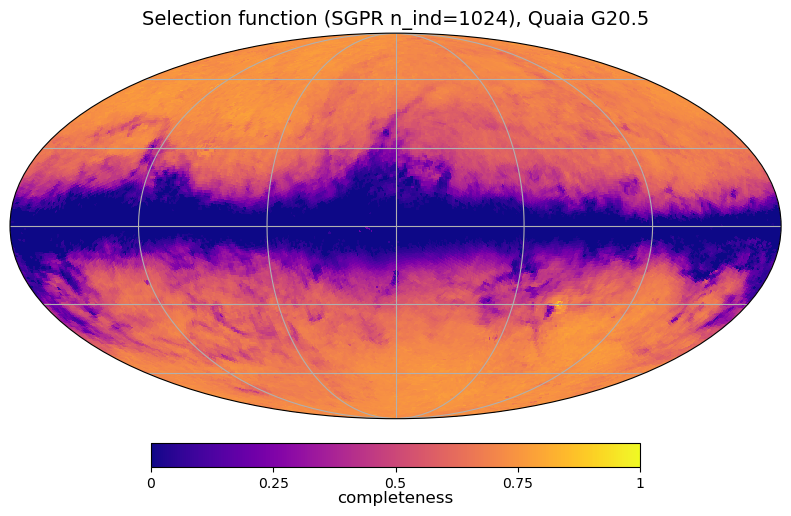

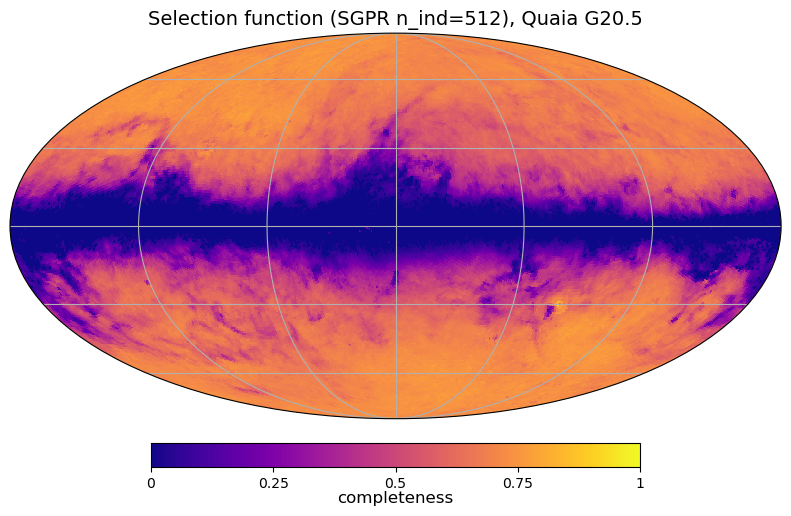

In [3]:
for name, m in maps_sf.items():
    projview(m, title=f"Selection function ({name}), Quaia G{G_hi}",
             unit="completeness", cmap=cmap_map, coord=['C', 'G'],
             graticule=True,
             min=0.0, max=1.0,
             cbar_ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
    plt.show()

## Residuals from the original

Residual = SGPR − orig, on pixels where the original map is populated (others masked). Color scale is symmetric, clipped to the 99th percentile of |residual|.

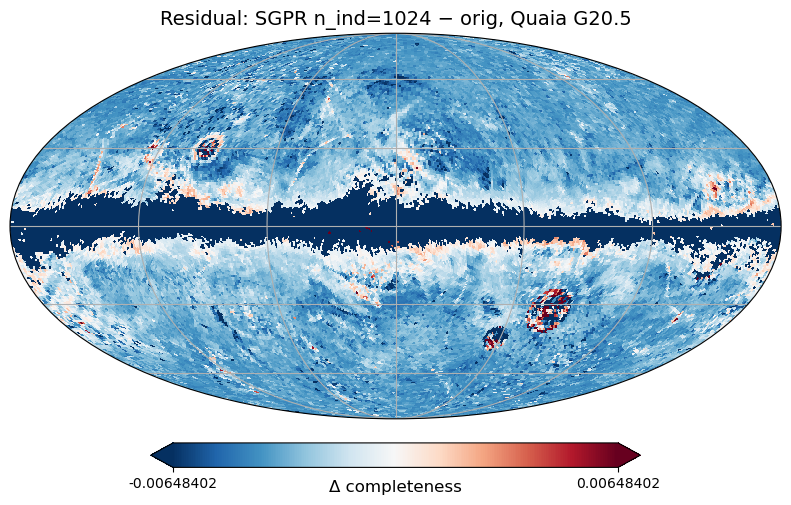

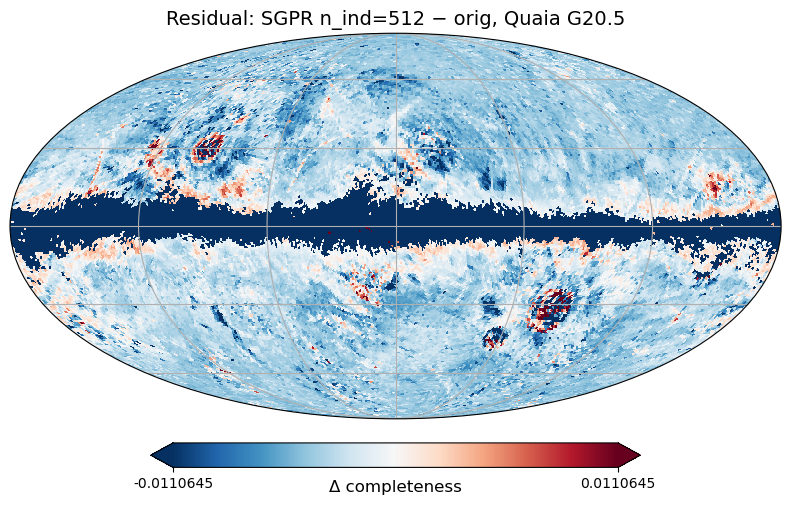

In [4]:
sgpr_names = ['SGPR n_ind=1024', 'SGPR n_ind=512']

for name in sgpr_names:
    resid = maps_sf[name] - orig
    resid_masked = resid.copy()
    resid_masked[~i_valid] = hp.UNSEEN
    vmax = np.percentile(np.abs(resid[i_valid]), 99)
    projview(resid_masked, title=f"Residual: {name} \u2212 orig, Quaia G{G_hi}",
             unit="\u0394 completeness", cmap=cmap_resid, coord=['C', 'G'],
             graticule=True,
             min=-vmax, max=vmax)
    plt.show()

## Statistics

All statistics computed on pixels where both the original and the SGPR map are positive and finite.

In [5]:
def compare(a, b):
    """Stats of b relative to reference a, on shared positive/finite pixels."""
    m = (a > 0) & (b > 0) & np.isfinite(a) & np.isfinite(b)
    d = b[m] - a[m]
    return {
        'N_pix': int(m.sum()),
        'Pearson_r': float(np.corrcoef(a[m], b[m])[0, 1]),
        'bias (mean diff)': float(np.mean(d)),
        'RMS diff': float(np.sqrt(np.mean(d**2))),
        'median |diff|': float(np.median(np.abs(d))),
        'max |diff|': float(np.max(np.abs(d))),
        'median |frac diff|': float(np.median(np.abs(d) / a[m])),
    }

rows = {name: compare(orig, maps_sf[name]) for name in sgpr_names}
df = pd.DataFrame(rows).T
pd.set_option('display.float_format', lambda x: f'{x:.5g}')
df

,N_pix,Pearson_r,bias (mean diff),RMS diff,median |diff|,max |diff|,median |frac diff|
SGPR n_ind=1024,42853,0.99995,-0.002828,0.0036035,0.0031516,0.12916,0.0052773
SGPR n_ind=512,42853,0.99988,-0.0030441,0.0045708,0.0033962,0.1232,0.0058467


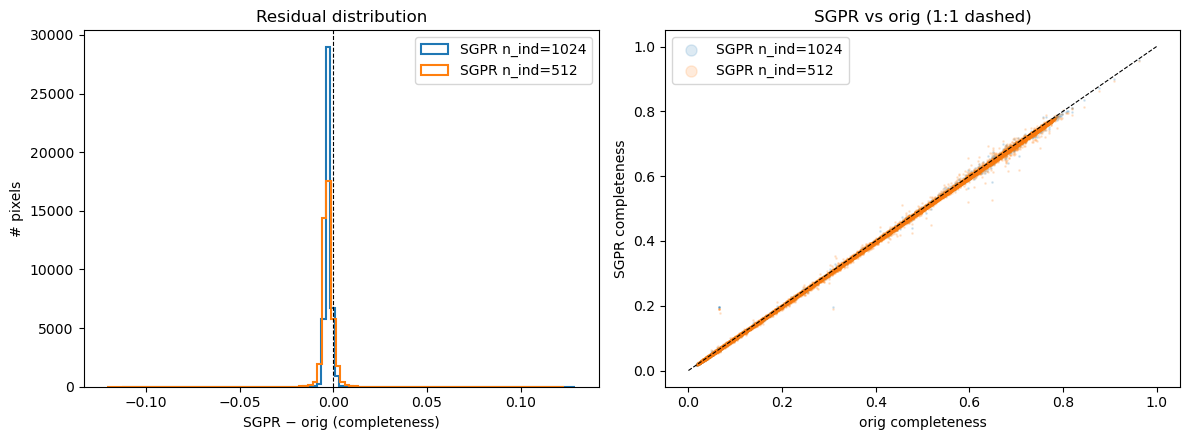

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# residual histograms
for name in sgpr_names:
    d = (maps_sf[name] - orig)[i_valid]
    axes[0].hist(d, bins=100, histtype='step', lw=1.5, label=name)
axes[0].axvline(0, color='k', lw=0.8, ls='--')
axes[0].set_xlabel('SGPR \u2212 orig (completeness)')
axes[0].set_ylabel('# pixels')
axes[0].set_title('Residual distribution')
axes[0].legend()

# scatter orig vs sgpr
for name in sgpr_names:
    axes[1].scatter(orig[i_valid], maps_sf[name][i_valid], s=1, alpha=0.15, label=name)
lims = [0, max(orig[i_valid].max(), 1.0)]
axes[1].plot(lims, lims, 'k--', lw=0.8)
axes[1].set_xlabel('orig completeness')
axes[1].set_ylabel('SGPR completeness')
axes[1].set_title('SGPR vs orig (1:1 dashed)')
axes[1].legend(markerscale=8)

plt.tight_layout()
plt.show()

In [7]:
# How much does dropping 1024 -> 512 inducing points change the map?
diff_512_1024 = compare(maps_sf['SGPR n_ind=1024'], maps_sf['SGPR n_ind=512'])
print('SGPR n_ind=512 vs n_ind=1024:')
for k, v in diff_512_1024.items():
    print(f'  {k:20s} {v:.5g}')

SGPR n_ind=512 vs n_ind=1024:
  N_pix                42853
  Pearson_r            0.99996
  bias (mean diff)     -0.00021611
  RMS diff             0.0017312
  median |diff|        0.00058749
  max |diff|           0.10332
  median |frac diff|   0.0010879
